Fitting 3 folds for each of 8 candidates, totalling 24 fits
Melhores hiperparâmetros: {'max_depth': 12, 'max_features': 'sqrt', 'max_samples': 0.7, 'min_samples_leaf': 8, 'min_samples_split': 11, 'n_estimators': 207}

--- Métricas do Modelo (Treino x Validação x Teste) ---
          Métrica Treino Validação  Teste
         Accuracy 0.9412    0.9403 0.9406
        Precision 0.9411    0.9402 0.9406
           Recall 1.0000    1.0000 0.9998
               F1 0.9696    0.9692 0.9693
               F2 0.9876    0.9874 0.9874
          ROC-AUC 0.9474    0.7436 0.7417
           PR-AUC 0.9960    0.9738 0.9732
Balanced Accuracy 0.5119    0.5037 0.5085
              MCC 0.1494    0.0832 0.1178
      Brier Score 0.0451    0.0539 0.0535
         Log Loss 0.1831    0.2168 0.2156

--- Relatório de Classificação - Treino ---
              precision    recall  f1-score   support

           0       1.00      0.02      0.05      1223
           1       0.94      1.00      0.97     19069

    accuracy 

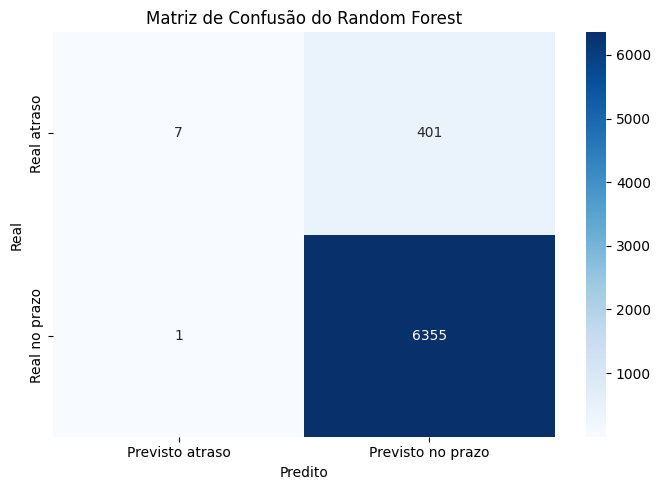

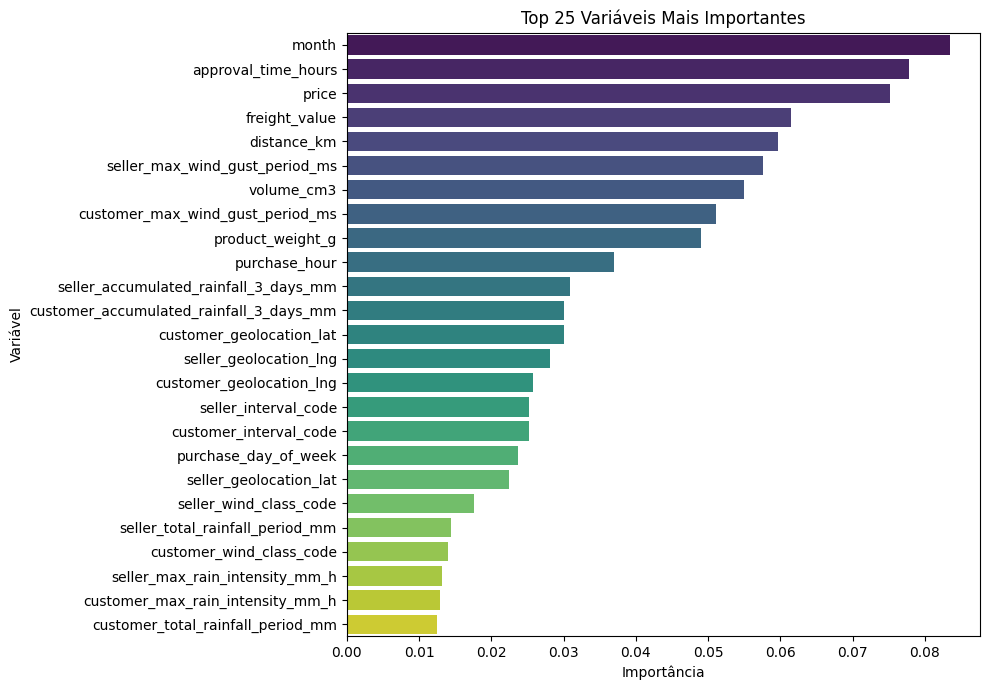

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    fbeta_score,
    roc_auc_score,
    average_precision_score,
    balanced_accuracy_score,
    matthews_corrcoef,
    brier_score_loss,
    log_loss,
    classification_report,
    confusion_matrix,
    precision_recall_curve,
    auc,
    make_scorer,
)
from scipy.stats import randint

# 1. Carregar a tabela final
csv_path = Path(r"c:\Users\otavi\OneDrive\Desktop\tcc\testes modelos\tabela-final.csv")
df = pd.read_csv(csv_path, index_col=0, delimiter=",")

# 2. Definir a variável alvo
# 1 = entregue no prazo | 0 = entregue com atraso
y = df["delivered_on_time"]

# 3. Remover colunas com vazamento de informação (leakage)
# Essas variáveis só existem depois que o pedido já foi entregue ou estão diretamente ligadas ao alvo.
leakage_candidates = [
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "handling_time_hours",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score",
]

# 4. Separar as variáveis de entrada da variável alvo
# errors='ignore' evita falha caso alguma coluna não exista no dataframe atual.
X = df.drop(columns=leakage_candidates + ["delivered_on_time"], errors="ignore")

# 5. Manter apenas variáveis numéricas
# O Random Forest do scikit-learn precisa de valores numéricos para treinar.
X = X.select_dtypes(include=[np.number])

# 6. Tratar valores ausentes
# Preenchimento simples com zero para manter o fluxo do notebook.
X = X.fillna(0)

# 7. Dividir os dados em treino, validação e teste
# A validação ajuda a reduzir overfit sem mexer no teste final.
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    random_state=42,
    stratify=y,
    shuffle=True,
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp,
    shuffle=True,
)

# 8. Definir uma grade mais conservadora para reduzir overfit
param_distributions = {
    "n_estimators": randint(120, 320),
    "max_depth": randint(5, 16),
    "min_samples_split": randint(10, 30),
    "min_samples_leaf": randint(4, 14),
    "max_features": ["sqrt", "log2"],
    "max_samples": [0.6, 0.7, 0.8],
}

# 9. Criar o modelo base
# A classe 0 representa atraso, então damos mais peso a ela sem exagerar.
base_model = RandomForestClassifier(
    random_state=42,
    class_weight={0: 2, 1: 1},
    n_jobs=-1,
    bootstrap=True,
)

# 10. Buscar a melhor combinação de hiperparâmetros
# A busca agora privilegia recall da classe de atraso, mas com árvores menos complexas.
recall_atraso_scorer = make_scorer(recall_score, pos_label=0)
search = RandomizedSearchCV(
    estimator=base_model,
    param_distributions=param_distributions,
    n_iter=8,
    scoring=recall_atraso_scorer,
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1,
)
search.fit(X_train, y_train)

# 11. Recuperar o melhor modelo encontrado
rf_model = search.best_estimator_
print("Melhores hiperparâmetros:", search.best_params_)

# 12. Gerar predições de treino, validação e teste
y_pred_train = rf_model.predict(X_train)
y_prob_train = rf_model.predict_proba(X_train)[:, 1]
y_pred_val = rf_model.predict(X_val)
y_prob_val = rf_model.predict_proba(X_val)[:, 1]
y_pred_test = rf_model.predict(X_test)
y_prob_test = rf_model.predict_proba(X_test)[:, 1]

# 13. Função para organizar métricas
# PR-AUC é calculado com average precision, que é mais estável para classe desbalanceada.
def calcular_metricas(y_true, y_pred, y_prob):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "F2": fbeta_score(y_true, y_pred, beta=2, zero_division=0),
        "ROC-AUC": roc_auc_score(y_true, y_prob),
        "PR-AUC": average_precision_score(y_true, y_prob),
        "Balanced Accuracy": balanced_accuracy_score(y_true, y_pred),
        "MCC": matthews_corrcoef(y_true, y_pred),
        "Brier Score": brier_score_loss(y_true, y_prob),
        "Log Loss": log_loss(y_true, y_prob),
    }

metricas_treino = calcular_metricas(y_train, y_pred_train, y_prob_train)
metricas_val = calcular_metricas(y_val, y_pred_val, y_prob_val)
metricas_teste = calcular_metricas(y_test, y_pred_test, y_prob_test)

# 14. Comparar métricas de treino, validação e teste
metrics_df = pd.DataFrame({
    "Métrica": list(metricas_treino.keys()),
    "Treino": list(metricas_treino.values()),
    "Validação": list(metricas_val.values()),
    "Teste": list(metricas_teste.values()),
})
for col in ["Treino", "Validação", "Teste"]:
    metrics_df[col] = metrics_df[col].map(lambda v: f"{v:.4f}")

print("\n--- Métricas do Modelo (Treino x Validação x Teste) ---")
print(metrics_df.to_string(index=False))

print("\n--- Relatório de Classificação - Treino ---")
print(classification_report(y_train, y_pred_train))

print("\n--- Relatório de Classificação - Validação ---")
print(classification_report(y_val, y_pred_val))

print("\n--- Relatório de Classificação - Teste ---")
print(classification_report(y_test, y_pred_test))

# 15. Plotar a matriz de confusão do teste
plt.figure(figsize=(7, 5))
sns.heatmap(
    confusion_matrix(y_test, y_pred_test),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Previsto atraso', 'Previsto no prazo'],
    yticklabels=['Real atraso', 'Real no prazo'],
)
plt.title('Matriz de Confusão do Random Forest')
plt.xlabel('Predito')
plt.ylabel('Real')
plt.tight_layout()
plt.show()

# 16. Plotar as 25 variáveis mais importantes
importances = rf_model.feature_importances_
feature_df = pd.DataFrame({"Feature": X.columns, "Importance": importances})
feature_df = feature_df.sort_values(by="Importance", ascending=False).head(25)

plt.figure(figsize=(10, 7))
sns.barplot(
    x="Importance",
    y="Feature",
    data=feature_df,
    hue="Feature",
    dodge=False,
    palette="viridis",
    legend=False,
)
plt.title('Top 25 Variáveis Mais Importantes')
plt.xlabel('Importância')
plt.ylabel('Variável')
plt.tight_layout()
plt.show()